In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')


In [3]:
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  str    
 1   Company              10959 non-null  str    
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    str    
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), str(3)
memory usage: 599.4 KB


In [5]:
df.isnull().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
dtype: int64

In [6]:
df.drop(columns = 'Event', inplace = True)

In [7]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = df.columns.str.lower()

In [10]:
df.columns

Index(['date', 'company', 'r&d_spending_usd_mn', 'ai_revenue_usd_mn',
       'ai_revenue_growth_%', 'stock_impact_%'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 10959 non-null  str    
 1   company              10959 non-null  str    
 2   r&d_spending_usd_mn  10959 non-null  float64
 3   ai_revenue_usd_mn    10959 non-null  float64
 4   ai_revenue_growth_%  10959 non-null  float64
 5   stock_impact_%       10959 non-null  float64
dtypes: float64(4), str(2)
memory usage: 513.8 KB


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 10959 non-null  datetime64[us]
 1   company              10959 non-null  str           
 2   r&d_spending_usd_mn  10959 non-null  float64       
 3   ai_revenue_usd_mn    10959 non-null  float64       
 4   ai_revenue_growth_%  10959 non-null  float64       
 5   stock_impact_%       10959 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 513.8 KB


In [14]:
df

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09
...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,0.22


## How much amount the  companies spent on R & D ?

In [15]:
amt = df.groupby('company')['r&d_spending_usd_mn'].sum()

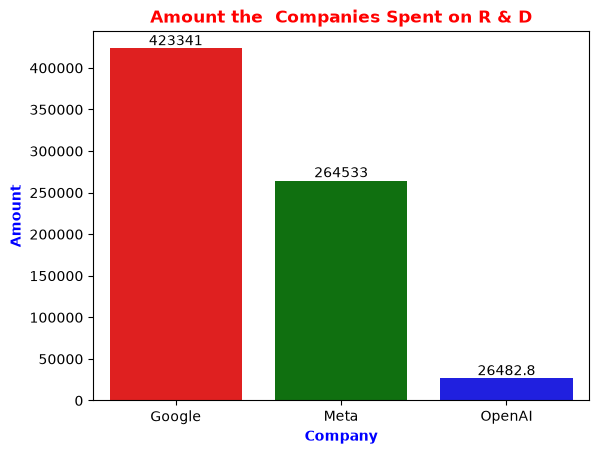

In [16]:
plt.title('Amount the  Companies Spent on R & D', fontweight = 'bold', color = 'red')
plt.xlabel('Company',fontweight = 'bold', color = 'blue')
plt.ylabel('Amount',fontweight = 'bold', color = 'blue')
ax = sns.barplot(x = amt.index, y = amt.values,palette = ['red','green','blue'],hue = amt.index)
for i in ax.containers:
    ax.bar_label(i)
plt.show()

## Revenue Earned by the companies

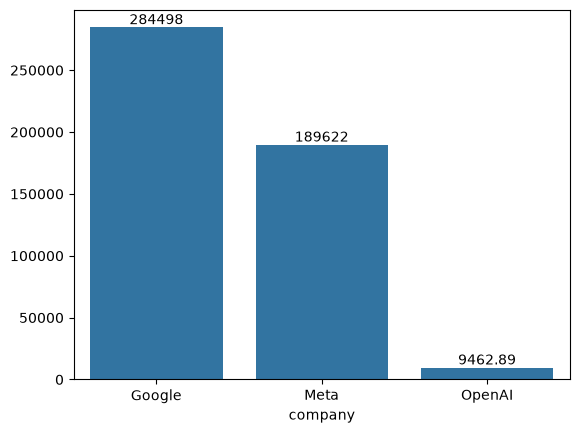

In [17]:
rev = df.groupby('company')['ai_revenue_usd_mn'].sum()
ax = sns.barplot(x = rev.index,y = rev.values)
for i in ax.containers:
    ax.bar_label(i)

## Datewise Impact on the Stock

In [18]:
df.head(2)

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41


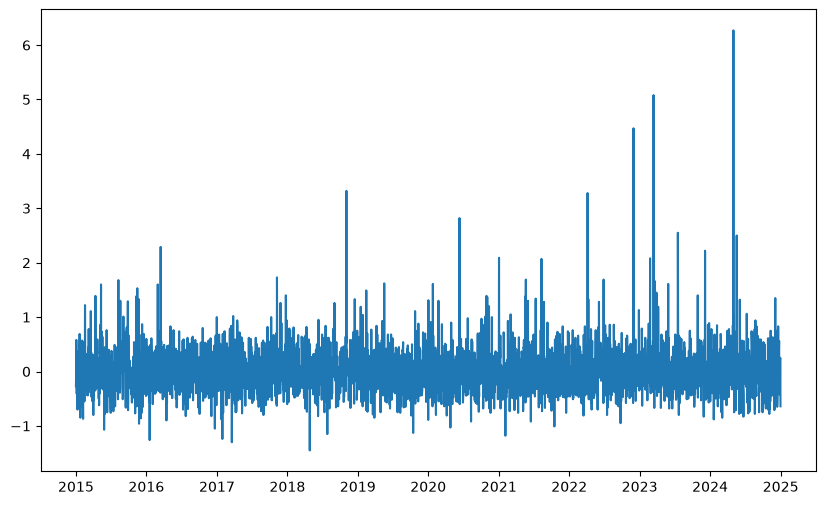

In [19]:
imp = df.groupby('date')['stock_impact_%'].mean().round(2)
plt.figure(figsize = (10,6))
plt.plot(imp.index, imp.values)
plt.show()

## Create 3 separate dataframes

## Events when Maximum Stock Impact was observed

In [20]:
df.groupby('date')['stock_impact_%'].max().sort_values(ascending = False)

date
2024-05-01    18.50
2023-03-14    15.20
2022-11-30    12.00
2022-04-06     9.80
2020-06-11     8.50
              ...  
2017-08-30    -0.76
2016-12-03    -0.78
2024-01-20    -0.81
2020-08-10    -0.86
2022-09-24    -0.88
Name: stock_impact_%, Length: 3653, dtype: float64

## AI Revenue Growth of the companies

In [21]:
df.head()

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09


<Axes: ylabel='company'>

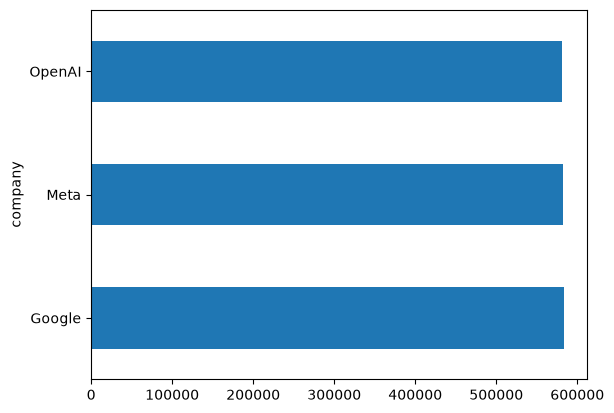

In [22]:
df.groupby('company')['ai_revenue_growth_%'].sum().plot(kind = 'barh')

# OpenAI's AI Revenue Growth year-by-year

In [23]:
df['year'] = df.date.dt.year

In [24]:
df

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09,2015
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,0.22,2024


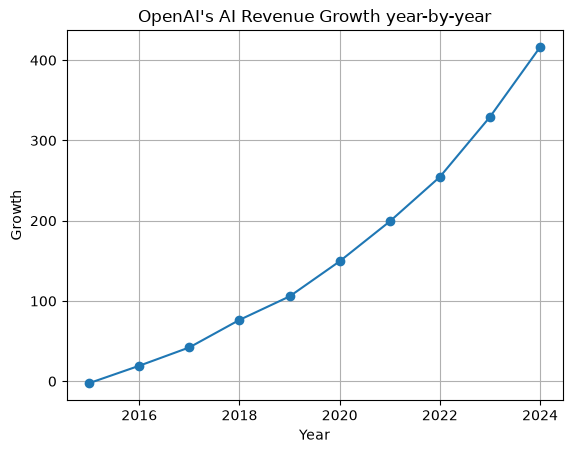

In [25]:
growth = df[df['company'] == 'OpenAI'].groupby('year')['ai_revenue_growth_%'].mean().round(2)
plt.title('''OpenAI's AI Revenue Growth year-by-year''')
plt.xlabel('Year')
plt.ylabel('Growth')
plt.grid()
plt.plot(growth.index, growth.values,marker = 'o')
plt.show()

##


## Expenditure vs Revenue year-by-year

In [26]:
df.head()

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09,2015


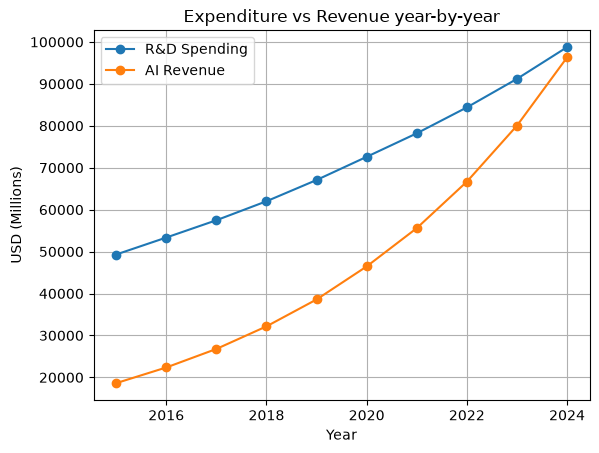

In [27]:
exp = df.groupby('year')['r&d_spending_usd_mn'].sum()
rev = df.groupby('year')['ai_revenue_usd_mn'].sum()
plt.title('Expenditure vs Revenue year-by-year')
plt.xlabel('Year')
plt.ylabel('USD (Millions)')
plt.grid()
plt.plot(exp.index, exp.values, label='R&D Spending',marker = 'o')
plt.plot(rev.index, rev.values, label='AI Revenue',marker = 'o')
plt.legend()
plt.show()


## Change in the index wrt Year & Company

In [28]:
df.head()

,date,company,r&d_spending_usd_mn,ai_revenue_usd_mn,ai_revenue_growth_%,stock_impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,-0.09,2015
